In [1]:
import numpy as np
from matplotlib import pyplot as plt
import deepxde as dde
dde.backend.set_default_backend("pytorch")

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "pytorch". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


In [2]:
k = 0.4
L = 1
n = 1

In [3]:
geom = dde.geometry.Interval(0,L)
timedomain = dde.geometry.TimeDomain(0,n)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

In [4]:
ic = dde.icbc.IC(geomtime, lambda x: np.sin(n* np.pi * x[:,0:1]/L), lambda _, on_initial: on_initial)

In [5]:
input_array = np.array([[1,2,3],
                        [4,5,6],
                        [7,8,9]])

lambda_function = lambda x : 2*x[:,0:1]

result_array = lambda_function(input_array)

print(result_array)

[[ 2]
 [ 8]
 [14]]


In [6]:
cond_lambda = lambda x : "Even" if x%2 == 0 else "Odd"
print(cond_lambda(4))
print(cond_lambda(3))

Even
Odd


In [7]:
def double_first_column(input_array):
    print("input_array", input_array)
    print("input_array.shape", input_array.shape)
    print("input_array[:, 0:1]", input_array[:, 0:1])
    print("input_array[:, 0:1].shape", input_array[:, 0:1].shape)
    print("input_array[:, 0]", input_array[:, 0])
    print("input_array[:, 0].shape", input_array[:, 0].shape)
    return 2 * input_array[:, 0:1]

bc = dde.icbc.DirichletBC(
    geomtime, 
    lambda input_array: double_first_column(input_array),
    lambda _,
    on_boundary: on_boundary)

In [8]:
def pde(comp,u):
    du_t = dde.grad.jacobian(u,comp, i=0,j=1)
    du_xx = dde.grad.hessian(u,comp, i=0,j=0)
    return du_t - k * du_xx

In [9]:
data = dde.data.TimePDE(geomtime,
                       pde,
                       [bc,ic],
                       num_domain = 2540,
                       num_boundary = 80,
                       num_initial = 160,
                       num_test = 2540,
                       )

In [10]:
net = dde.nn.FNN([2] + [20]*3+ [1], "tanh", "Glorot normal")

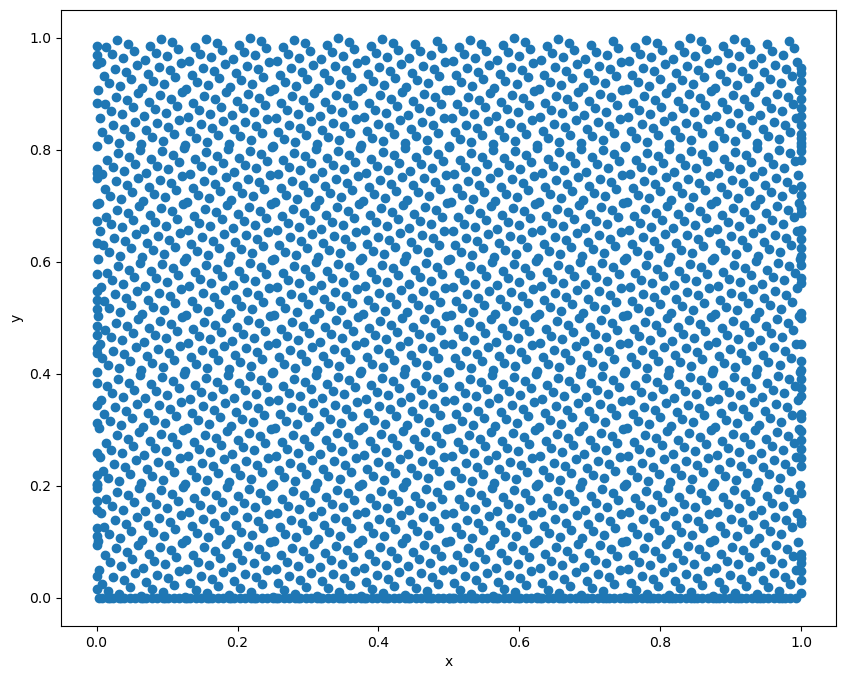

In [11]:
plt.figure(figsize = (10,8))
plt.scatter(data.train_x_all[:,0],data.train_x_all[:,1])
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [12]:
model = dde.Model(data, net)

In [13]:
model.compile("adam", lr=1e-3)

Compiling model...
'compile' took 0.000215 s



In [14]:
losshistory, train_state = model.train(iterations = 15000)

Training model...

input_array [[1.        0.25     ]
 [1.        0.71875  ]
 [1.        0.453125 ]
 [0.        0.15625  ]
 [1.        0.6953125]
 [1.        0.9453125]
 [1.        0.6875   ]
 [1.        0.828125 ]
 [1.        0.328125 ]
 [1.        0.8125   ]
 [0.        0.21875  ]
 [0.        0.171875 ]
 [0.        0.3125   ]
 [0.        0.8828125]
 [1.        0.734375 ]
 [0.        0.203125 ]
 [1.        0.921875 ]
 [0.        0.0390625]
 [1.        0.609375 ]
 [0.        0.53125  ]
 [1.        0.625    ]
 [0.        0.703125 ]
 [0.        0.34375  ]
 [1.        0.234375 ]
 [0.        0.671875 ]
 [1.        0.1875   ]
 [1.        0.9375   ]
 [0.        0.578125 ]
 [1.        0.5625   ]
 [1.        0.0078125]
 [0.        0.765625 ]
 [1.        0.0625   ]
 [1.        0.296875 ]
 [0.        0.75     ]
 [0.        0.953125 ]
 [1.        0.875    ]
 [1.        0.78125  ]
 [0.        0.3828125]
 [1.        0.8203125]
 [1.        0.359375 ]
 [1.        0.03125  ]
 [1.        0.5703125]
 [0

Step      Train loss                        Test loss                         Test metric
0         [1.74e-02, 7.05e-01, 1.65e-01]    [1.56e-02, 7.05e-01, 1.65e-01]    []  
1000      [7.26e-03, 5.43e-02, 4.69e-02]    [3.29e-03, 5.43e-02, 4.69e-02]    []  
2000      [5.93e-03, 3.12e-02, 1.96e-02]    [3.72e-03, 3.12e-02, 1.96e-02]    []  
3000      [4.67e-03, 2.43e-02, 1.59e-02]    [3.25e-03, 2.43e-02, 1.59e-02]    []  
4000      [3.34e-03, 2.01e-02, 1.36e-02]    [2.21e-03, 2.01e-02, 1.36e-02]    []  
5000      [6.41e-03, 1.62e-02, 1.36e-02]    [3.08e-03, 1.62e-02, 1.36e-02]    []  
6000      [2.63e-03, 1.48e-02, 1.13e-02]    [1.74e-03, 1.48e-02, 1.13e-02]    []  
7000      [2.30e-03, 1.28e-02, 1.05e-02]    [1.47e-03, 1.28e-02, 1.05e-02]    []  
8000      [2.10e-03, 1.13e-02, 9.54e-03]    [1.38e-03, 1.13e-02, 9.54e-03]    []  
9000      [1.93e-03, 9.90e-03, 8.87e-03]    [1.32e-03, 9.90e-03, 8.87e-03]    []  
10000     [1.75e-03, 8.64e-03, 8.43e-03]    [1.16e-03, 8.64e-03, 8.43e-03]    []

In [15]:
#Limited-memory Broyden-Fletcher-Goldfarb-Shanno
model.compile("L-BFGS-B")
losshistory, train_state = model.train()

Compiling model...
'compile' took 0.001468 s

Training model...

Step      Train loss                        Test loss                         Test metric
15000     [1.13e-03, 6.08e-03, 4.14e-03]    [8.53e-04, 6.08e-03, 4.14e-03]    []  

Best model at step 15000:
  train loss: 1.14e-02
  test loss: 1.11e-02
  test metric: []

'train' took 0.006477 s



Saving loss history to /Users/erfantaatizadeh/Downloads/loss.dat ...
Saving training data to /Users/erfantaatizadeh/Downloads/train.dat ...
Saving test data to /Users/erfantaatizadeh/Downloads/test.dat ...


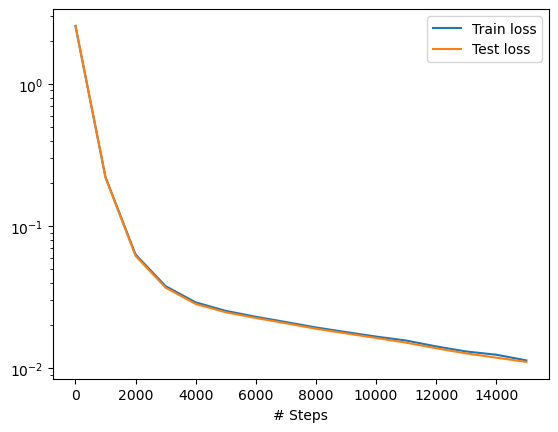

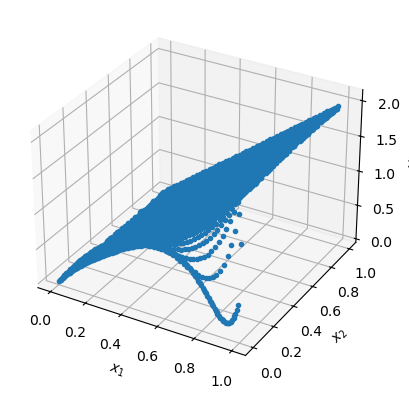

In [16]:
dde.saveplot(losshistory,train_state, issave= True, isplot=True)